<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [18]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [3]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [4]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


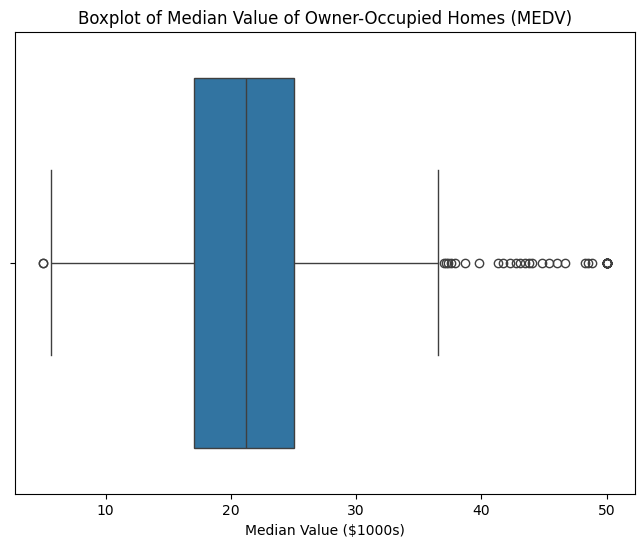

In [6]:
#  Boxplot for MEDV
pyplot.figure(figsize=(8, 6))
sns.boxplot(x=boston_df['MEDV'])
pyplot.title('Boxplot of Median Value of Owner-Occupied Homes (MEDV)')
pyplot.xlabel('Median Value ($1000s)')
pyplot.show()

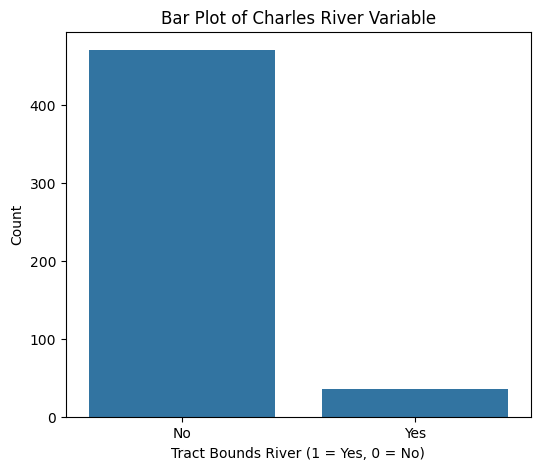

In [8]:
#  Bar Plot for CHAS
pyplot.figure(figsize=(6, 5))
sns.countplot(x='CHAS', data=boston_df)
pyplot.title('Bar Plot of Charles River Variable')
pyplot.xlabel('Tract Bounds River (1 = Yes, 0 = No)')
pyplot.ylabel('Count')
pyplot.xticks([0, 1], ['No', 'Yes'])
pyplot.show()

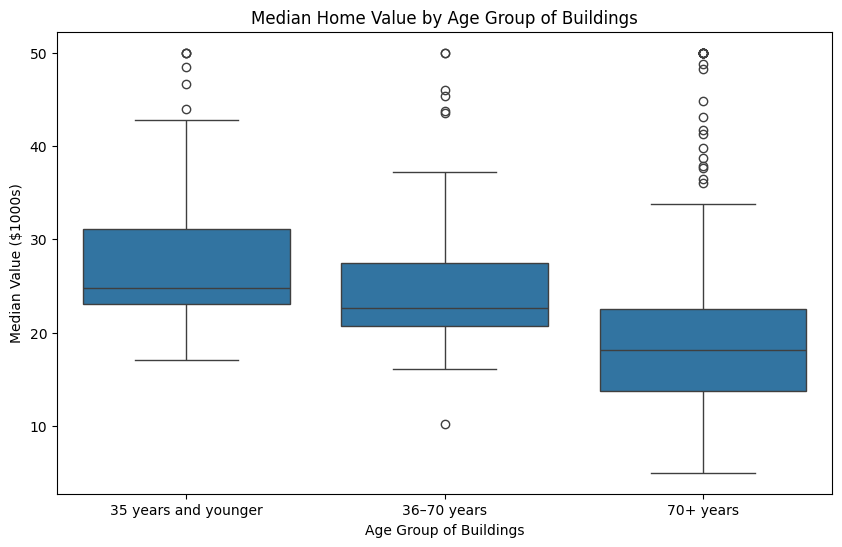

In [12]:
#  Boxplot of MEDV vs AGE (discretized)
bins = [0, 35, 70, 100]
labels = ['35 years and younger', '36–70 years', '70+ years']
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'], bins=bins, labels=labels, right=True)

pyplot.figure(figsize=(10, 6))
sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df)
pyplot.title('Median Home Value by Age Group of Buildings')
pyplot.xlabel('Age Group of Buildings')
pyplot.ylabel('Median Value ($1000s)')
pyplot.show()

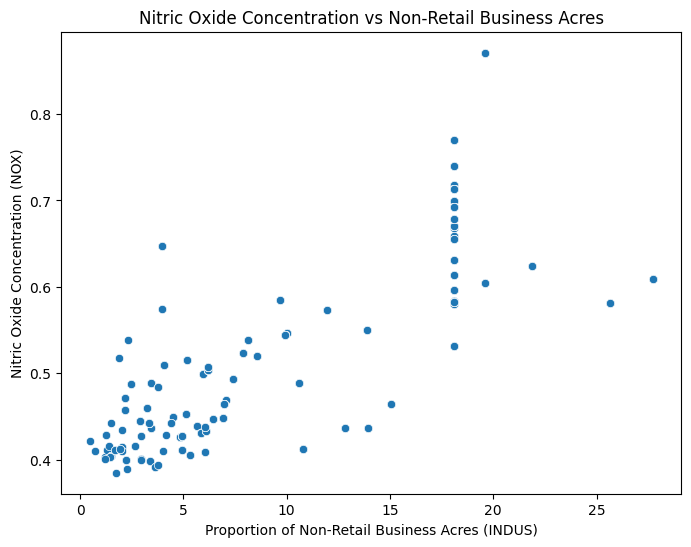

In [13]:
# Scatter plot: NOX vs INDUS
pyplot.figure(figsize=(8, 6))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
pyplot.title('Nitric Oxide Concentration vs Non-Retail Business Acres')
pyplot.xlabel('Proportion of Non-Retail Business Acres (INDUS)')
pyplot.ylabel('Nitric Oxide Concentration (NOX)')
pyplot.show()

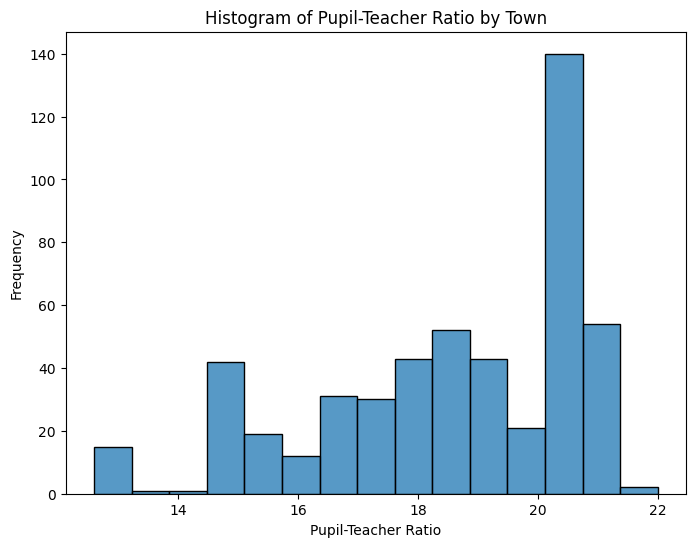

In [14]:
# Histogram of PTRATIO
pyplot.figure(figsize=(8, 6))
sns.histplot(boston_df['PTRATIO'], kde=False, bins=15)
pyplot.title('Histogram of Pupil-Teacher Ratio by Town')
pyplot.xlabel('Pupil-Teacher Ratio')
pyplot.ylabel('Frequency')
pyplot.show()

In [22]:
#H0 = No difference in house values between the two groups (bounded vs not bounded).
#H1 = There is a significant difference in house values between the two groups.
#  T-test: MEDV vs CHAS
medv_river = boston_df[boston_df['CHAS'] == 1]['MEDV']
medv_no_river = boston_df[boston_df['CHAS'] == 0]['MEDV']
t_stat, p_val = scipy.stats.ttest_ind(medv_river, medv_no_river, equal_var=False)
print(f"1. T-test for MEDV by Charles River boundary:")
print(f"   T-statistic = {t_stat:.4f}, P-value = {p_val:.4f}")
if p_val < 0.05:
    print("   -> Reject H0: Significant difference in median home values.\n")
else:
    print("   -> Fail to reject H0: No significant difference.\n")

1. T-test for MEDV by Charles River boundary:
   T-statistic = 3.1133, P-value = 0.0036
   -> Reject H0: Significant difference in median home values.



In [23]:
#H0 = No difference in house values across different categories of AGE.
#H1 = There is a significant difference in house values across at least one category of AGE.
# ANOVA: MEDV vs AGE_GROUP
group1 = boston_df[boston_df['AGE_GROUP'] == '35 years and younger']['MEDV']
group2 = boston_df[boston_df['AGE_GROUP'] == '36–70 years']['MEDV']
group3 = boston_df[boston_df['AGE_GROUP'] == '70+ years']['MEDV']
f_stat, p_val = scipy.stats.f_oneway(group1, group2, group3)
print(f"2. ANOVA for MEDV by Age Group:")
print(f"   F-statistic = {f_stat:.4f}, P-value = {p_val:.4f}")
if p_val < 0.05:
    print("   -> Reject H0: At least one group differs significantly.\n")
else:
    print("   -> Fail to reject H0: No significant difference between groups.\n")


2. ANOVA for MEDV by Age Group:
   F-statistic = 36.4076, P-value = 0.0000
   -> Reject H0: At least one group differs significantly.



In [25]:
#H0 = No linear relationship between Nitric oxide and non-retail business acres.
#H1 = There is a significant linear relationship between Nitric oxide and non-retail business acres.
# Pearson Correlation: NOX vs INDUS
corr_coef, p_val = scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])
print(f"3. Pearson Correlation between NOX and INDUS:")
print(f"   Correlation coefficient = {corr_coef:.4f}, P-value = {p_val:.4f}")
if p_val < 0.05:
    print("   -> Reject H0: Significant linear relationship.\n")
else:
    print("   -> Fail to reject H0: No significant linear relationship.\n")


3. Pearson Correlation between NOX and INDUS:
   Correlation coefficient = 0.7637, P-value = 0.0000
   -> Reject H0: Significant linear relationship.



In [26]:
#H0 = The additional distance to employment centers does not significantly impact house values.
#H1 = The additional distance to employment centers significantly impacts house values.
# Regression: Impact of DIS on MEDV
X = boston_df['DIS']
y = boston_df['MEDV']
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print("4. Regression Analysis: MEDV ~ DIS")
print(model.summary())

p_val = model.pvalues['DIS']
if p_val < 0.05:
    print("   -> Reject H0: Distance has a significant impact on home value.\n")
else:
    print("   -> Fail to reject H0: Distance has no significant impact.\n")

4. Regression Analysis: MEDV ~ DIS
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           1.21e-08
Time:                        07:23:21   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.